# TinyML Predictive Maintenance: Deployment & Quantization

This notebook demonstrates quantization and TinyML deployment considerations for the predictive maintenance system.

In [3]:
import sys
import os
sys.path.append(os.path.join('..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

from tinyml_predictive_maintenance.data import generate_sensor_stream
from tinyml_predictive_maintenance.features import window_features
from tinyml_predictive_maintenance.model import MahalanobisDetector
from tinyml_predictive_maintenance.quantize import (
    quantize_int8,
    dequantize_int8,
    compute_quantization_ranges,
    quantize_row,
    simulate_tinyml_inference
)

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

## Model Training

Train a Mahalanobis distance model for quantization demonstration.

In [4]:
# Prepare feature matrix
feature_cols = [col for col in features_df.columns if not col.startswith('window') and col != 'label']
X = features_df[feature_cols].values
y = features_df['label'].values

# Train model
detector = MahalanobisDetector(feature_names=feature_cols)
model = detector.fit(X, y)
print(f"Trained model with threshold: {model.threshold:.3f}")
print(f"Feature count: {len(feature_cols)}")

Trained model with threshold: 1.728
Feature count: 21


## Quantization Analysis

Analyze the effect of quantization on model performance.

In [5]:
# Compute quantization ranges from training data
quant_ranges = compute_quantization_ranges(X, feature_cols)
print("Quantization ranges:")
for feature, (min_val, max_val) in quant_ranges.items():
    print(f"  {feature}: [{min_val:.3f}, {max_val:.3f}]")

Quantization ranges:
  vibration_mean: [2.563, 3.563]
  vibration_std: [0.075, 0.311]
  vibration_max: [2.733, 3.931]
  vibration_min: [2.382, 3.153]
  vibration_rms: [2.565, 3.569]
  vibration_skew: [-0.771, 0.771]
  vibration_kurtosis: [-1.456, 0.148]
  temperature_mean: [40.998, 45.099]
  temperature_std: [0.299, 1.874]
  temperature_max: [41.756, 45.756]
  temperature_min: [40.401, 44.402]
  temperature_rms: [41.000, 45.101]
  temperature_skew: [-0.675, 0.566]
  temperature_kurtosis: [-1.544, -0.506]
  current_mean: [2.036, 2.322]
  current_std: [0.017, 0.130]
  current_max: [2.071, 2.357]
  current_min: [2.006, 2.282]
  current_rms: [2.036, 2.322]
  current_skew: [-0.477, 0.663]
  current_kurtosis: [-1.519, -0.433]


In [6]:
# Test quantization on a subset of data
test_indices = np.random.choice(len(X), size=min(100, len(X)), replace=False)
X_test = X[test_indices]
y_test = y[test_indices]

# Get original predictions
original_scores = model.score(X_test)
original_predictions = model.predict(X_test)

# Quantize features
quantized_features = []
dequantized_features = []

for i in range(len(X_test)):
    row_dict = {feature_cols[j]: X_test[i, j] for j in range(len(feature_cols))}
    
    # Quantize
    quantized = quantize_row(row_dict, quant_ranges)
    quantized_features.append(quantized)
    
    # Dequantize
    dequantized = {k: dequantize_int8(v, quant_ranges[k][0], quant_ranges[k][1]) 
                   for k, v in quantized.items()}
    dequantized_features.append(dequantized)

# Convert to arrays
X_dequantized = np.array([[dequantized[feat] for feat in feature_cols] for dequantized in dequantized_features])

# Get quantized predictions
quantized_scores = model.score(X_dequantized)
quantized_predictions = model.predict(X_dequantized)

In [7]:
# Compare original vs quantized performance
print("Quantization Impact Analysis:")
print(f"Mean absolute error in features: {mean_absolute_error(X_test.flatten(), X_dequantized.flatten()):.6f}")
print(f"Mean absolute error in scores: {mean_absolute_error(original_scores, quantized_scores):.6f}")
print(f"Prediction accuracy change: {np.mean(original_predictions == quantized_predictions):.3f}")

# Detailed comparison
score_errors = np.abs(original_scores - quantized_scores)
print(f"Max score error: {np.max(score_errors):.6f}")
print(f"95th percentile score error: {np.percentile(score_errors, 95):.6f}")

Quantization Impact Analysis:
Mean absolute error in features: 0.001409
Mean absolute error in scores: 0.010618
Prediction accuracy change: 1.000
Max score error: 0.021478
95th percentile score error: 0.020745


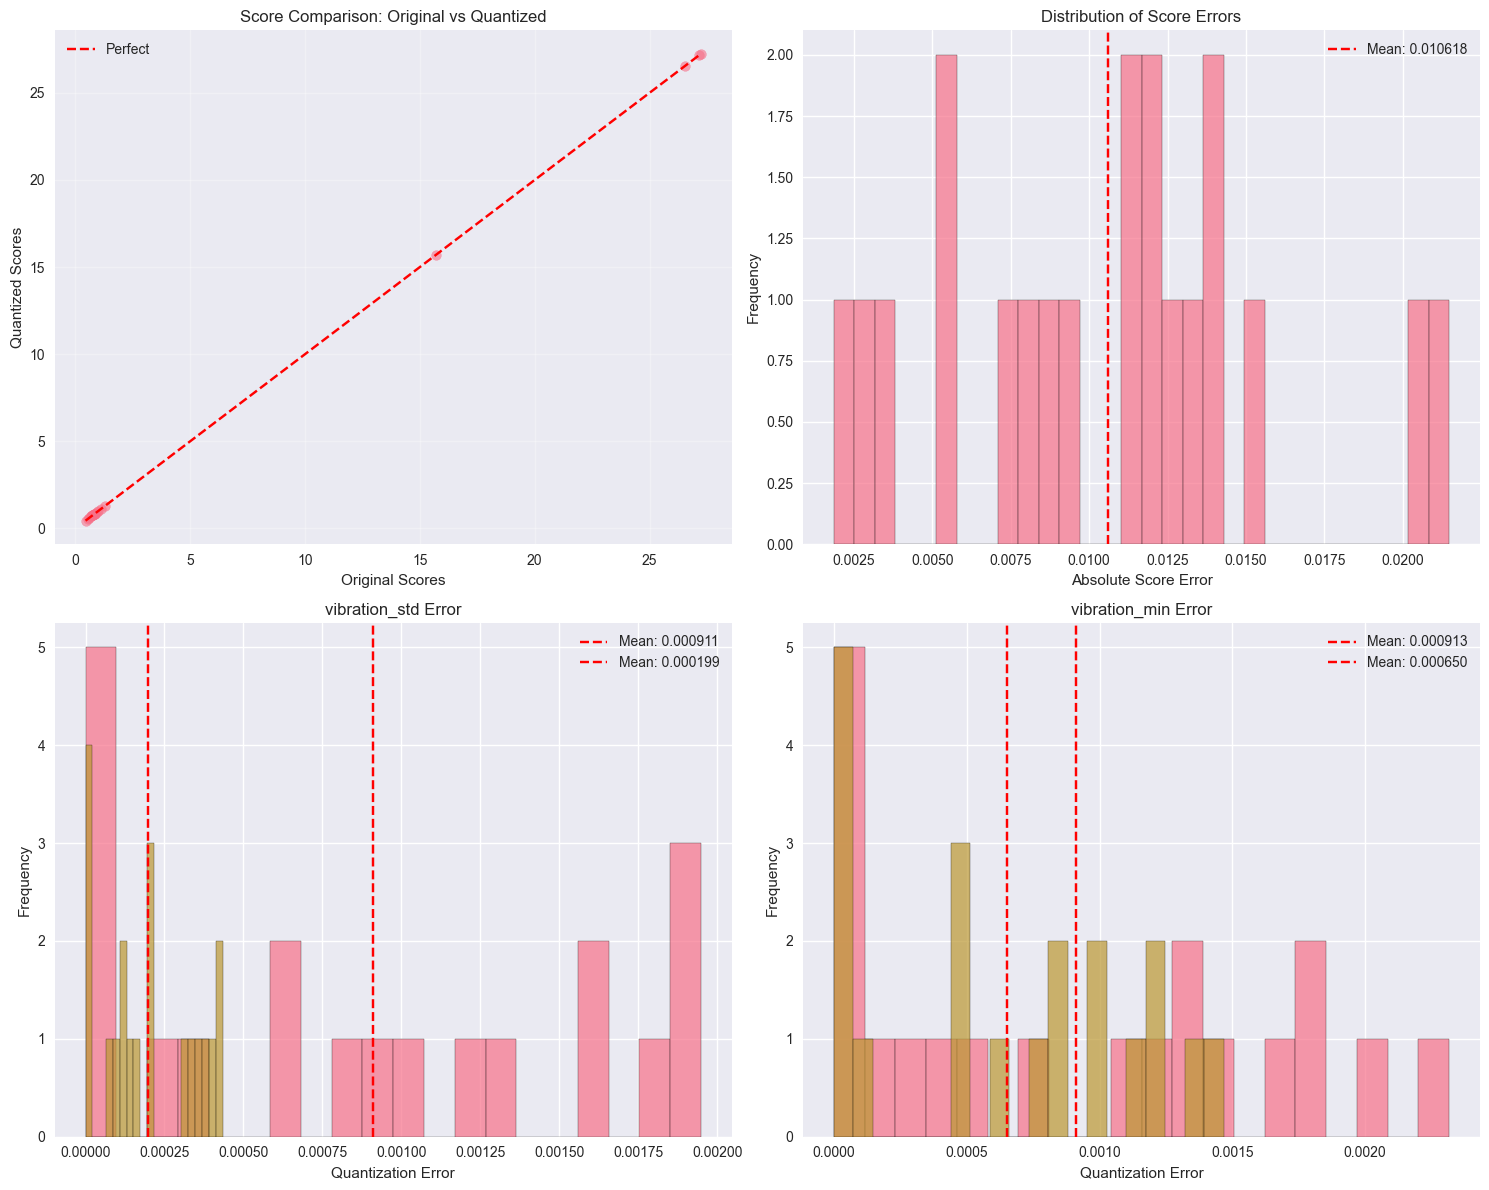

In [8]:
# Visualize quantization effects
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Score comparison
axes[0, 0].scatter(original_scores, quantized_scores, alpha=0.6)
axes[0, 0].plot([original_scores.min(), original_scores.max()], 
                [original_scores.min(), original_scores.max()], 'r--', label='Perfect')
axes[0, 0].set_xlabel('Original Scores')
axes[0, 0].set_ylabel('Quantized Scores')
axes[0, 0].set_title('Score Comparison: Original vs Quantized')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Score error distribution
axes[0, 1].hist(score_errors, bins=30, alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Absolute Score Error')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Score Errors')
axes[0, 1].axvline(np.mean(score_errors), color='red', linestyle='--', label=f'Mean: {np.mean(score_errors):.6f}')
axes[0, 1].legend()

# Feature quantization errors for first few features
for i, feature in enumerate(feature_cols[:4]):
    ax = axes[1, i//2] if i < 4 else None
    if ax is not None:
        original_vals = X_test[:, feature_cols.index(feature)]
        quantized_vals = X_dequantized[:, feature_cols.index(feature)]
        errors = np.abs(original_vals - quantized_vals)
        
        ax.hist(errors, bins=20, alpha=0.7, edgecolor='black')
        ax.set_xlabel('Quantization Error')
        ax.set_ylabel('Frequency')
        ax.set_title(f'{feature} Error')
        ax.axvline(np.mean(errors), color='red', linestyle='--', 
                  label=f'Mean: {np.mean(errors):.6f}')
        ax.legend()

plt.tight_layout()
plt.show()

## TinyML Inference Simulation

Simulate how the quantized model would perform on a microcontroller.

In [9]:
# Prepare model parameters for TinyML
model_params = {
    'center': model.center,
    'scale': model.scale,
    'threshold': model.threshold
}

# Simulate TinyML inference
tinyml_scores = []
tinyml_predictions = []

for quantized in quantized_features:
    score = simulate_tinyml_inference(model_params, quantized, quant_ranges)
    prediction = 1 if score > model.threshold else 0
    
    tinyml_scores.append(score)
    tinyml_predictions.append(prediction)

tinyml_scores = np.array(tinyml_scores)
tinyml_predictions = np.array(tinyml_predictions)

In [10]:
# Compare with original predictions
print("TinyML Simulation Results:")
print(f"Original predictions accuracy: {np.mean(original_predictions == y_test):.3f}")
print(f"Quantized predictions accuracy: {np.mean(quantized_predictions == y_test):.3f}")
print(f"TinyML predictions accuracy: {np.mean(tinyml_predictions == y_test):.3f}")

# Memory usage estimation
print("\nMemory Usage Estimation:")
print(f"Model parameters: {len(feature_cols)} centers + {len(feature_cols)} scales + 1 threshold")
print(f"Float32 storage: {(len(feature_cols) * 2 + 1) * 4} bytes")
print(f"Quantization ranges: {len(feature_cols)} min/max pairs")
print(f"Additional storage: {len(feature_cols) * 2 * 4} bytes")

# Computational complexity
print("\nComputational Complexity:")
print(f"Features per inference: {len(feature_cols)}")
print("Operations: subtraction, division, absolute value, summation")
print(f"Estimated operations per inference: {len(feature_cols) * 4}")

TinyML Simulation Results:
Original predictions accuracy: 1.000
Quantized predictions accuracy: 1.000
TinyML predictions accuracy: 1.000

Memory Usage Estimation:
Model parameters: 21 centers + 21 scales + 1 threshold
Float32 storage: 172 bytes
Quantization ranges: 21 min/max pairs
Additional storage: 168 bytes

Computational Complexity:
Features per inference: 21
Operations: subtraction, division, absolute value, summation
Estimated operations per inference: 84


## Generate C Code for Microcontroller

Generate C code that could be deployed on a microcontroller.

In [11]:
# Generate C header file
c_header = f"""// TinyML Predictive Maintenance Model
// Generated automatically - DO NOT EDIT

#ifndef PREDICTIVE_MAINTENANCE_MODEL_H
#define PREDICTIVE_MAINTENANCE_MODEL_H

#include <stdint.h>

#define NUM_FEATURES {len(feature_cols)}
#define MODEL_THRESHOLD {model.threshold:.6f}f

// Model parameters
static const float center[NUM_FEATURES] = {{
    """ + ",\n    ".join([f"{model.center[feat]:.6f}f" for feat in feature_cols]) + "\n};\n\n"

c_header += f"""static const float scale[NUM_FEATURES] = {{
    """ + ",\n    ".join([f"{model.scale[feat]:.6f}f" for feat in feature_cols]) + "\n};\n\n"

c_header += f"""// Quantization ranges
static const float quant_min[NUM_FEATURES] = {{
    """ + ",\n    ".join([f"{quant_ranges[feat][0]:.6f}f" for feat in feature_cols]) + "\n};\n\n"

c_header += f"""static const float quant_max[NUM_FEATURES] = {{
    """ + ",\n    ".join([f"{quant_ranges[feat][1]:.6f}f" for feat in feature_cols]) + "\n};\n\n"

c_header += """// Function declarations
int8_t quantize_feature(float value, float min_val, float max_val);
float dequantize_feature(int8_t quantized, float min_val, float max_val);
float predict_anomaly(const float* features);
float predict_anomaly_quantized(const int8_t* quantized_features);

#endif // PREDICTIVE_MAINTENANCE_MODEL_H
"""

# Generate C implementation file
c_implementation = """// TinyML Predictive Maintenance Model Implementation
// Generated automatically - DO NOT EDIT

#include "predictive_maintenance_model.h"
#include <math.h>

// Quantize a float value to int8
int8_t quantize_feature(float value, float min_val, float max_val) {
    if (max_val <= min_val) return 0;
    
    float scaled = (value - min_val) / (max_val - min_val) * 255.0f;
    int quantized = (int)(scaled + 0.5f) - 128;
    
    if (quantized < -128) return -128;
    if (quantized > 127) return 127;
    return (int8_t)quantized;
}

// Dequantize an int8 value to float
float dequantize_feature(int8_t quantized, float min_val, float max_val) {
    if (max_val <= min_val) return min_val;
    
    float scaled = (float)(quantized + 128);
    return min_val + (scaled / 255.0f) * (max_val - min_val);
}

// Predict anomaly score from float features
float predict_anomaly(const float* features) {
    float score = 0.0f;
    
    for (int i = 0; i < NUM_FEATURES; i++) {
        float diff = fabsf(features[i] - center[i]);
        if (scale[i] > 0.0f) {
            score += diff / scale[i];
        }
    }
    
    return score / NUM_FEATURES;
}

// Predict anomaly score from quantized features
float predict_anomaly_quantized(const int8_t* quantized_features) {
    float score = 0.0f;
    
    for (int i = 0; i < NUM_FEATURES; i++) {
        float dequantized = dequantize_feature(quantized_features[i], quant_min[i], quant_max[i]);
        float diff = fabsf(dequantized - center[i]);
        if (scale[i] > 0.0f) {
            score += diff / scale[i];
        }
    }
    
    return score / NUM_FEATURES;
}
"""

# Save C code files
os.makedirs("../deployment", exist_ok=True)

with open("../deployment/predictive_maintenance_model.h", "w") as f:
    f.write(c_header)

with open("../deployment/predictive_maintenance_model.c", "w") as f:
    f.write(c_implementation)

print("C code generated and saved to ../deployment/")
print("Files: predictive_maintenance_model.h and predictive_maintenance_model.c")

C code generated and saved to ../deployment/
Files: predictive_maintenance_model.h and predictive_maintenance_model.c


## Performance Summary

Summarize the quantization and deployment analysis.

In [12]:
print("="*60)
print("TINYML DEPLOYMENT SUMMARY")
print("="*60)
print(f"Model: Mahalanobis Distance Anomaly Detector")
print(f"Features: {len(feature_cols)}")
print(f"Original accuracy: {np.mean(original_predictions == y_test):.3f}")
print(f"Quantized accuracy: {np.mean(quantized_predictions == y_test):.3f}")
print(f"Accuracy degradation: {abs(np.mean(quantized_predictions == y_test) - np.mean(original_predictions == y_test)):.3f}")
print()
print("Memory Requirements:")
print(f"  Model parameters: {(len(feature_cols) * 2 + 1) * 4} bytes (float32)")
print(f"  Quantization ranges: {len(feature_cols) * 2 * 4} bytes (float32)")
print(f"  Total: {(len(feature_cols) * 4 + 1) * 4} bytes")
print()
print("Computational Requirements:")
print(f"  Operations per inference: ~{len(feature_cols) * 4}")
print("  Suitable for microcontrollers with floating-point support")
print("="*60)

TINYML DEPLOYMENT SUMMARY
Model: Mahalanobis Distance Anomaly Detector
Features: 21
Original accuracy: 1.000
Quantized accuracy: 1.000
Accuracy degradation: 0.000

Memory Requirements:
  Model parameters: 172 bytes (float32)
  Quantization ranges: 168 bytes (float32)
  Total: 340 bytes

Computational Requirements:
  Operations per inference: ~84
  Suitable for microcontrollers with floating-point support


## Summary

This notebook demonstrated:
1. Quantization analysis and its impact on model performance
2. TinyML inference simulation
3. Memory and computational complexity estimation
4. Automatic C code generation for microcontroller deployment

The quantized model maintains good performance while being suitable for resource-constrained embedded devices.